<p style="text-align:center;">
    <font face="Georgia" size=6 color="red"><b>Install & Import Required libraries </b></font>
</p>

In [ ]:
import os
import re
import shutil
import torch
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
import supervision as sv
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [1]:
# Clone the SAM2 repository from GitHub to the local environment
!git clone https://github.com/facebookresearch/sam2.git


Cloning into 'sam2'...
remote: Enumerating objects: 1070, done.
remote: Total 1070 (delta 0), reused 0 (delta 0), pack-reused 1070 (from 1)
Receiving objects: 100% (1070/1070), 128.11 MiB | 35.97 MiB/s, done.
Resolving deltas: 100% (381/381), done.


In [2]:
#  Download the "train.yaml" configuration file from Google Drive and save it to the specified directory
!wget -O /kaggle/working/sam2/sam2/configs/train.yaml 'https://drive.usercontent.google.com/download?id=11cmbxPPsYqFyWq87tmLgBAQ6OZgEhPG3'

--2025-07-15 07:25:39--  https://drive.usercontent.google.com/download?id=11cmbxPPsYqFyWq87tmLgBAQ6OZgEhPG3
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 108.177.11.132, 2607:f8b0:400c:c13::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|108.177.11.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11055 (11K) [application/octet-stream]
Saving to: ‘/kaggle/working/sam2/sam2/configs/train.yaml’

/kaggle/working/sam 100%[===================>]  10.80K  --.-KB/s    in 0s      

2025-07-15 07:25:41 (43.2 MB/s) - ‘/kaggle/working/sam2/sam2/configs/train.yaml’ saved [11055/11055]



In [3]:
# Change the current working directory to "/kaggle/working/sam2/"
%cd /kaggle/working/sam2/


/kaggle/working/sam2


In [4]:
# Install the required dependencies for development from the current directory in editable mode
!pip install -e .[dev] -q 


  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 27.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 427.5/427.5 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 

In [5]:
# Navigate to the "checkpoints" directory and execute the "download_ckpts.sh" script to download checkpoints

!cd ./checkpoints && ./download_ckpts.sh  

--2025-07-15 07:31:22--  https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_tiny.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 18.164.78.81, 18.164.78.128, 18.164.78.72, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|18.164.78.81|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 156008466 (149M) [application/vnd.snesdev-page-table]
Saving to: ‘sam2.1_hiera_tiny.pt’

sam2.1_hiera_tiny.p 100%[===================>] 148.78M   287MB/s    in 0.5s    

2025-07-15 07:31:23 (287 MB/s) - ‘sam2.1_hiera_tiny.pt’ saved [156008466/156008466]

--2025-07-15 07:31:23--  https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 18.164.78.72, 18.164.78.81, 18.164.78.121, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|18.164.78.72|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 184416285 (176M) [applic

In [10]:
# Install the "supervision" package 
!pip install supervision -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 3.9 MB/s eta 0:00:00a 0:00:01


<p style="text-align:center;">
    <font face="Georgia" size=5 color="red"><b> load Dataset</b></font>
</p>

In [ ]:
# It is a Data Set link :
# https://universe.roboflow.com/brad-dwyer/car-parts-pgo19/dataset/6

In [15]:

root_path = "/kaggle/input/carforsam2"

# Get the list of folders in the root path
folders = [f for f in os.listdir(root_path) if os.path.isdir(os.path.join(root_path, f))]

print(f"Number of folders: {len(folders)}\n")

for folder in folders:
    folder_path = os.path.join(root_path, folder)
    files = os.listdir(folder_path)
    # Only files that are images
    image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f"{folder}: {len(image_files)} images")


Number of folders: 3

valid: 11 images
test: 1 images
train: 38 images


In [6]:
# Data path in /kaggle/input/
FOLDER = "/kaggle/input/carforsam2/train"  

# New path to copy the files
NEW_FOLDER = "/kaggle/working/train"

# Create the new directory
os.makedirs(NEW_FOLDER, exist_ok=True)

# Copy files to the new directory
for filename in os.listdir(FOLDER):
    shutil.copy(os.path.join(FOLDER, filename), os.path.join(NEW_FOLDER, filename))

# Rename files in the new directory
for filename in os.listdir(NEW_FOLDER):
    new_filename = filename.replace(".", "_", filename.count(".") - 1)
    if not re.search(r"_\d+\.\w+$", new_filename):
        new_filename = new_filename.replace(".", "_1.")
    os.rename(os.path.join(NEW_FOLDER, filename), os.path.join(NEW_FOLDER, new_filename))

print("Files have been renamed and copied to the new folder.")


Files have been renamed and copied to the new folder.


<p style="text-align:center;">
    <font face="Georgia" size=5 color="red"><b>Editing Yaml File</b></font>
</p>

In [7]:
# Open the train.yaml file for editing

with open('/kaggle/working/sam2/sam2/configs/train.yaml', 'r') as f:
    yaml_content = f.read()

# Change data paths and other paths
yaml_content = yaml_content.replace('/content/data/train', '/kaggle/working/train')

# Write the updated file
with open('/kaggle/working/sam2/sam2/configs/train.yaml', 'w') as f:
    f.write(yaml_content)

print("train.yaml has been updated successfully.")


train.yaml has been updated successfully.


<p style="text-align:center;">
    <font face="Georgia" size=5 color="red"><b>Training</b></font>
</p>

In [8]:
!python training/train.py -c 'configs/train.yaml' --use-cluster 0 --num-gpus 1 


###################### Train App Config ####################
scratch:
  resolution: 1024
  train_batch_size: 1
  num_train_workers: 10
  num_frames: 1
  max_num_objects: 3
  base_lr: 5.0e-06
  vision_lr: 3.0e-06
  phases_per_epoch: 1
  num_epochs: 40
dataset:
  img_folder: /kaggle/working/train
  gt_folder: /kaggle/working/train
  multiplier: 2
vos:
  train_transforms:
  - _target_: training.dataset.transforms.ComposeAPI
    transforms:
    - _target_: training.dataset.transforms.RandomHorizontalFlip
      consistent_transform: true
    - _target_: training.dataset.transforms.RandomAffine
      degrees: 25
      shear: 20
      image_interpolation: bilinear
      consistent_transform: true
    - _target_: training.dataset.transforms.RandomResizeAPI
      sizes: ${scratch.resolution}
      square: true
      consistent_transform: true
    - _target_: training.dataset.transforms.ColorJitter
      consistent_transform: true
      brightness: 0.1
      contrast: 0.03
      saturation: 0.03

<p style="text-align:center;">
    <font face="Georgia" size=5 color="red"><b>Evaluation</b></font>
</p>

In [9]:
%load_ext tensorboard
%tensorboard --bind_all --logdir ./sam2_logs/

<IPython.core.display.Javascript object>


image 1/1 /kaggle/input/carforsam2/test/te44_jpg.rf.ef911ea20f5873ff8733afab40c81817.jpg: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 4723.3ms
Speed: 4.5ms preprocess, 4723.3ms inference, 0.6ms postprocess per image at shape (1, 3, 1024, 1024)


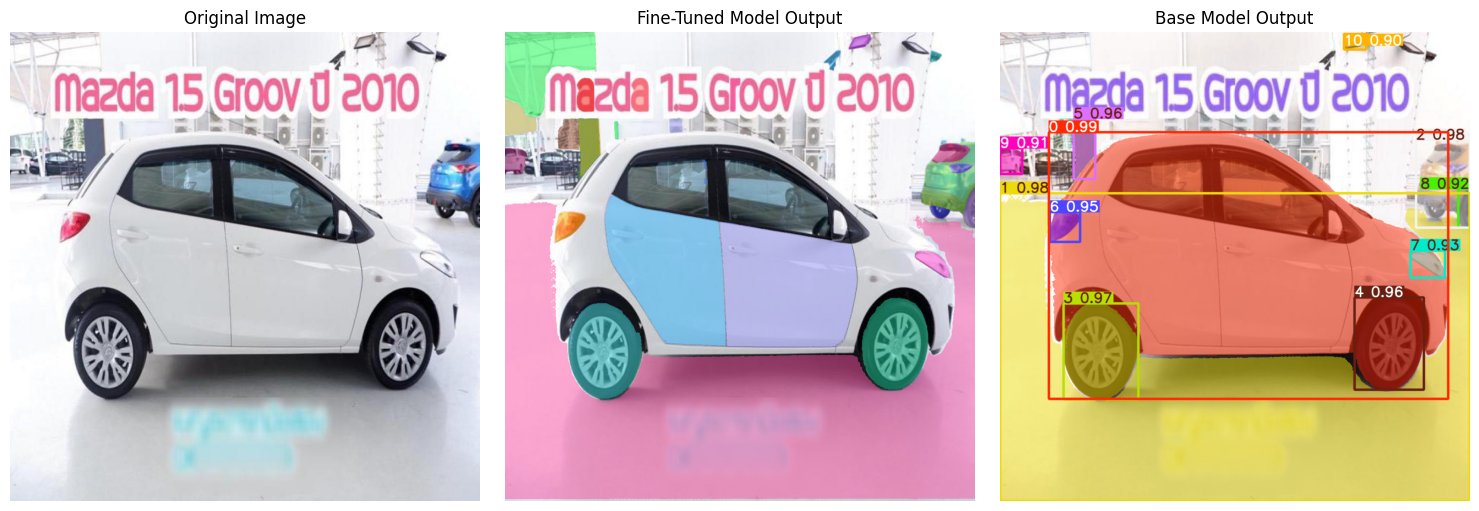

In [16]:

# Fine-tuned model
checkpoint = "/kaggle/working/sam2/sam2_logs/configs/train.yaml/checkpoints/checkpoint.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_b+.yaml"

# Build model and mask generator
sam2 = build_sam2(model_cfg, checkpoint, device="cuda")
mask_generator = SAM2AutomaticMaskGenerator(sam2)

# Path to the target image
image_path = "/kaggle/input/carforsam2/test/te44_jpg.rf.ef911ea20f5873ff8733afab40c81817.jpg"

# Open the image
opened_image = np.array(Image.open(image_path).convert("RGB"))

# Generate mask using the fine-tuned model
result_finetuned = mask_generator.generate(opened_image)

# Convert to detections
detections_finetuned = sv.Detections.from_sam(sam_result=result_finetuned)

# Annotate the image
mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)
annotated_image_finetuned = mask_annotator.annotate(opened_image.copy(), detections=detections_finetuned)

# Base model (Ultralytics SAM)
!pip install ultralytics --quiet
from ultralytics import SAM
model_base = SAM("sam2.1_b.pt")  

# Generate output from the base model
result_base = model_base(image_path)

# Display images in a row with three columns
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Display the original image
axs[0].imshow(opened_image)
axs[0].set_title("Original Image")
axs[0].axis('off')

# Display output from the fine-tuned model
axs[1].imshow(annotated_image_finetuned)
axs[1].set_title("Fine-Tuned Model Output")
axs[1].axis('off')

# Display output from the base model
axs[2].imshow(result_base[0].plot())  
axs[2].set_title("Base Model Output")
axs[2].axis('off')

# Show all images
plt.tight_layout()
plt.show()


<p style="text-align:center;">
    <font face="Georgia" size=5 color="red"><b>Evaluation on Another Dataset</b></font>
</p>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.6 MB/s eta 0:00:0000:0100:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 154M/154M [00:00<00:00, 264MB/s] 



image 1/1 /kaggle/input/visdrone-dataset/VisDrone2019-DET-train/VisDrone2019-DET-train/images/0000002_00005_d_0000014.jpg: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 1 21, 1 22, 1 23, 1 24, 1 25, 1 26, 1 27, 1 28, 1 29, 1 30, 1 31, 4649.3ms
Speed: 9.0ms preprocess, 4649.3ms inference, 1.2ms postprocess per image at shape (1, 3, 1024, 1024)


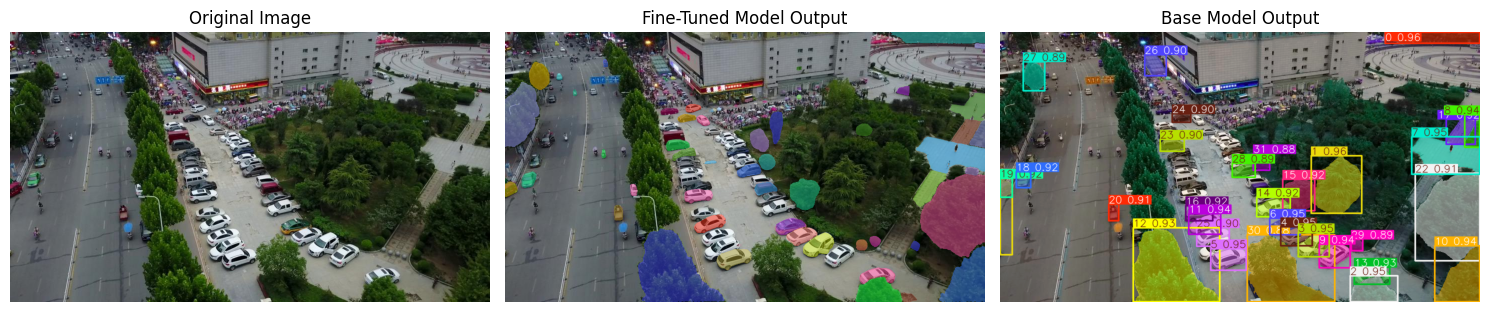

In [13]:
# Fine-tuned model
checkpoint = "/kaggle/working/sam2/sam2_logs/configs/train.yaml/checkpoints/checkpoint.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_b+.yaml"

# Build model and mask generator
sam2 = build_sam2(model_cfg, checkpoint, device="cuda")
mask_generator = SAM2AutomaticMaskGenerator(sam2)

# Path to the target image
image_path = "/kaggle/input/visdrone-dataset/VisDrone2019-DET-train/VisDrone2019-DET-train/images/0000002_00005_d_0000014.jpg"

# Open the image
opened_image = np.array(Image.open(image_path).convert("RGB"))

# Generate mask using the fine-tuned model
result_finetuned = mask_generator.generate(opened_image)

# Convert to detections
detections_finetuned = sv.Detections.from_sam(sam_result=result_finetuned)

# Annotate the image
mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)
annotated_image_finetuned = mask_annotator.annotate(opened_image.copy(), detections=detections_finetuned)

# Base model (Ultralytics SAM)
!pip install ultralytics --quiet
from ultralytics import SAM
model_base = SAM("sam2.1_b.pt") 

# Generate output from the base model
result_base = model_base(image_path)

# Display images in a row with three columns
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Display the original image
axs[0].imshow(opened_image)
axs[0].set_title("Original Image")
axs[0].axis('off')

# Display output from the fine-tuned model
axs[1].imshow(annotated_image_finetuned)
axs[1].set_title("Fine-Tuned Model Output")
axs[1].axis('off')

# Display output from the base model
axs[2].imshow(result_base[0].plot())  
axs[2].set_title("Base Model Output")
axs[2].axis('off')

# Show all images
plt.tight_layout()
plt.show()


In [ ]:
# Sahar Abdi